In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# ============================================================
# NCAA DIVISION I SOFTBALL — DATA CLEANING PIPELINE
# ============================================================


# ------------------------------------------------------------
# 1. LOAD RAW DATA
# ------------------------------------------------------------

raw = pd.read_csv("2026_d1_raw.csv", header=None)


# ------------------------------------------------------------
# 2. LOCATE EACH NCAA STATISTICAL TABLE
# ------------------------------------------------------------

# Every table has a header row beginning with "Rank".
table_starts = raw.index[raw[0] == "Rank"]


# ------------------------------------------------------------
# 3. FUNCTION TO EXTRACT ONE TABLE
# ------------------------------------------------------------

def extract_table(raw, start, end):

    # Determine this table's columns from its header.
    columns = raw.loc[start].dropna().tolist()
    n_columns = len(columns)

    # Extract the section belonging to this statistical table.
    table = raw.loc[
        start + 1:end - 1,
        :n_columns - 1
    ].copy()

    # If this table contains a Reclassifying section,
    # keep only the regular Division I teams above it.
    reclassifying_rows = table.index[
        table[0] == "Reclassifying"
    ]

    if len(reclassifying_rows) > 0:
        reclassifying_start = reclassifying_rows[0]
        table = table.loc[
            table.index < reclassifying_start
        ]

    # Keep legitimate team rows.
    # Column 2 contains a numeric observation for team rows.
    valid_rows = pd.to_numeric(
        table[2],
        errors="coerce"
    ).notna()

    table = table[valid_rows]

    # Apply actual table headers.
    table.columns = columns

    # Reset row numbering.
    table = table.reset_index(drop=True)

    return table


# ------------------------------------------------------------
# 4. EXTRACT ALL NCAA TABLES
# ------------------------------------------------------------

tables = {}

# All tables except the final one.
for i, start in enumerate(table_starts[:-1]):

    end = table_starts[i + 1]

    # NCAA statistic title is four rows above its header.
    title = raw.loc[start - 4, 0]

    tables[title] = extract_table(
        raw,
        start,
        end
    )


# Final table uses the end of the raw dataframe.
last_start = table_starts[-1]
last_title = raw.loc[last_start - 4, 0]

tables[last_title] = extract_table(
    raw,
    last_start,
    len(raw)
)


# ------------------------------------------------------------
# 5. SELECT VARIABLES FOR MASTER DATASET
# ------------------------------------------------------------

features = {

    # General / offensive totals
    "Division IShutouts": ["SHO"],
    "Division IWalks": ["BB"],
    "Division IDoubles": ["2B"],
    "Division IDouble Plays": ["DP"],
    "Division ITriples": ["3B"],
    "Division IHome Runs": ["HR"],
    "Division IRuns Batted In": ["RBI"],
    "Division IHits": ["H"],

    # Offensive rate statistics
    "Division IRBIs Per Game": ["PG"],
    "Division IBatting Average": ["BA"],
    "Division IScoring": ["PG"],
    "Division IHome Runs per game": ["PG"],
    "Division IDoubles per Game": ["PG"],
    "Division ITriples per Game": ["PG"],
    "Division ISlugging Percentage": ["SLG PCT"],
    "Division IOn Base Percentage": ["PCT"],

    # Baserunning
    "Division ITotal Stolen Bases": ["SB"],
    "Division IStolen Bases per Game": ["CS", "PG"],

    # Pitching
    "Division IEarned Run Average": ["ERA"],
    "Division IHits Allowed Per Seven Innings": ["PG"],
    "Division IHit Batters": ["HB"],
    "Division IWHIP": ["WHIP"],
    "Division IStrikeout-to-Walk Ratio": ["K/BB"],
    "Division ITeam Strikeouts Per Seven Innings": ["K/7"],

    # Defense
    "Division IFielding Percentage": ["PCT"],
    "Division IDouble Plays per Game": ["PG"],
    "Division ITriple Plays": ["TP"],

    # Other offensive events
    "Division IHit By Pitch": ["HBP"],
    "Division ITotal Sacrifice Bunts": ["SH"],
    "Division ITotal Sacrifice Flies": ["SF"],

    # Team success
    "Division ITotal Runs": ["R"],
    "Division IWL Percentage": ["W", "L", "T", "PCT"]
}


# ------------------------------------------------------------
# 6. RENAME AMBIGUOUS NCAA COLUMN NAMES
# ------------------------------------------------------------

rename_features = {

    "Division IRBIs Per Game":
        {"PG": "RBI_PG"},

    "Division IScoring":
        {"PG": "RUNS_PG"},

    "Division IHome Runs per game":
        {"PG": "HR_PG"},

    "Division IDoubles per Game":
        {"PG": "2B_PG"},

    "Division ITriples per Game":
        {"PG": "3B_PG"},

    "Division IStolen Bases per Game":
        {"PG": "SB_PG"},

    "Division IHits Allowed Per Seven Innings":
        {"PG": "HITS_ALLOWED_7"},

    "Division IFielding Percentage":
        {"PCT": "FLD_PCT"},

    "Division IDouble Plays per Game":
        {"PG": "DP_PG"},

    "Division IOn Base Percentage":
        {"PCT": "OBP"},

    "Division IWL Percentage":
        {"PCT": "WIN_PCT"}
}


# ------------------------------------------------------------
# 7. BUILD ONE-ROW-PER-TEAM MASTER DATASET
# ------------------------------------------------------------

master = None

for table_name, columns in features.items():

    temp = tables[table_name][
        ["Name"] + columns
    ].copy()

    # Give repeated NCAA labels meaningful names.
    if table_name in rename_features:
        temp = temp.rename(
            columns=rename_features[table_name]
        )

    if master is None:
        master = temp

    else:
        master = master.merge(
            temp,
            on="Name",
            how="outer"
        )


master = master.rename(
    columns={"Name": "Team"}
)


# ------------------------------------------------------------
# 8. ADD GAMES PLAYED
# ------------------------------------------------------------

games = tables[
    "Division ITotal Runs"
][["Name", "G"]].copy()

games["G"] = pd.to_numeric(
    games["G"],
    errors="coerce"
)

master = master.merge(
    games,
    left_on="Team",
    right_on="Name",
    how="left"
)

master = master.drop(columns="Name")


# Put games played immediately after team name.
column_order = master.columns.tolist()

column_order.remove("G")
column_order.insert(1, "G")

master = master[column_order]


# ------------------------------------------------------------
# 9. STANDARDIZE COLUMN NAMES
# ------------------------------------------------------------

master = master.rename(
    columns={
        "SLG PCT": "SLG_PCT"
    }
)


# ------------------------------------------------------------
# 10. CONVERT STATISTICS TO NUMERIC DATA
# ------------------------------------------------------------

numeric_columns = master.columns.drop("Team")

master[numeric_columns] = master[
    numeric_columns
].apply(
    pd.to_numeric,
    errors="coerce"
)


# ------------------------------------------------------------
# 11. HANDLE KNOWN STRUCTURAL MISSING VALUES
# ------------------------------------------------------------

# Triple-play table contains only teams that recorded a
# triple play. Absence therefore represents zero.
master["TP"] = master["TP"].fillna(0)

# Shutout table contains teams with >= 1 shutout.
# Teams absent from that table recorded zero.
master["SHO"] = master["SHO"].fillna(0)


# ------------------------------------------------------------
# 12. RECOVER MISSING HOME-RUN TOTALS
# ------------------------------------------------------------

# Some teams are absent from the total-HR table even though
# NCAA reports their HR/game value. Recover approximate totals
# using HR/game × games played.
#
# NCAA rate statistics are rounded, so these are reconstructed
# rather than directly observed values.

missing_hr = (
    master["HR"].isna()
    & master["HR_PG"].notna()
    & master["G"].notna()
)

master.loc[missing_hr, "HR"] = (
    master.loc[missing_hr, "HR_PG"]
    * master.loc[missing_hr, "G"]
).round()


# If HR/game itself is missing, leave it missing rather than
# assuming zero without supporting evidence.


# ------------------------------------------------------------
# 13. SORT BY TEAM
# ------------------------------------------------------------

master = (
    master
    .sort_values("Team")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 14. FINAL DATA-QUALITY CHECKS
# ------------------------------------------------------------

print("MASTER DATASET")
print("--------------")

print("Shape:", master.shape)

print(
    "Duplicate teams:",
    master["Team"].duplicated().sum()
)

print("\nMissing values:")
print(
    master.isna()
          .sum()
          .loc[lambda x: x > 0]
          .sort_values(ascending=False)
)

print("\nData types:")
print(master.dtypes)

print("\nPreview:")
display(master.head(10))

# ------------------------------------------------------------
# 15. SAVE CLEAN DATASET
# ------------------------------------------------------------

master.to_csv(
    "ncaa_softball_2026_team_stats.csv",
    index=False
)

print("Saved ncaa_softball_2026_team_stats.csv")

MASTER DATASET
--------------
Shape: (304, 38)
Duplicate teams: 0

Missing values:
K/7      4
HR       1
HR_PG    1
dtype: int64

Data types:
Team               object
G                   int64
SHO               float64
BB                  int64
2B                  int64
DP                  int64
3B                  int64
HR                float64
RBI                 int64
H                   int64
RBI_PG            float64
BA                float64
RUNS_PG           float64
HR_PG             float64
2B_PG             float64
3B_PG             float64
SLG_PCT           float64
OBP               float64
SB                  int64
CS                  int64
SB_PG             float64
ERA               float64
HITS_ALLOWED_7    float64
HB                  int64
WHIP              float64
K/BB              float64
K/7               float64
FLD_PCT           float64
DP_PG             float64
TP                float64
HBP                 int64
SH                  int64
SF                  int64


,Team,G,SHO,BB,2B,DP,3B,HR,RBI,H,...,DP_PG,TP,HBP,SH,SF,R,W,L,T,WIN_PCT
0,A&M-Corpus Christi,53,2.0,169,38,19,11,5.0,123,278,...,0.36,0.0,24,21,9,156,14,39,0,0.264
1,Abilene Christian,48,1.0,111,62,13,10,29.0,165,322,...,0.27,0.0,20,9,10,185,7,41,0,0.146
2,Akron,60,4.0,223,76,19,12,56.0,308,465,...,0.32,0.0,22,12,16,331,35,25,0,0.583
3,Alabama,65,24.0,236,77,13,9,102.0,387,526,...,0.20,0.0,51,30,17,406,56,9,0,0.862
4,Alabama A&M,50,1.0,164,68,8,21,32.0,303,436,...,0.16,0.0,44,16,23,337,19,31,0,0.380
5,Alabama St.,56,3.0,164,72,13,27,24.0,263,420,...,0.23,0.0,35,43,17,301,24,32,0,0.429
6,Alcorn,50,2.0,126,46,9,12,19.0,189,333,...,0.18,0.0,16,33,13,225,15,34,1,0.310
7,App State,50,6.0,199,60,7,7,77.0,321,401,...,0.14,0.0,33,18,19,349,29,21,0,0.580
8,Arizona,55,10.0,168,65,46,10,68.0,365,478,...,0.84,0.0,27,18,17,401,37,18,0,0.673
9,Arizona St.,63,4.0,206,105,23,5,99.0,413,550,...,0.37,0.0,60,17,13,440,45,18,0,0.714


Saved ncaa_softball_2026_team_stats.csv


count    304.000000
mean       0.494845
std        0.165005
min        0.026000
25%        0.388750
50%        0.509500
75%        0.610250
max        0.867000
Name: WIN_PCT, dtype: float64


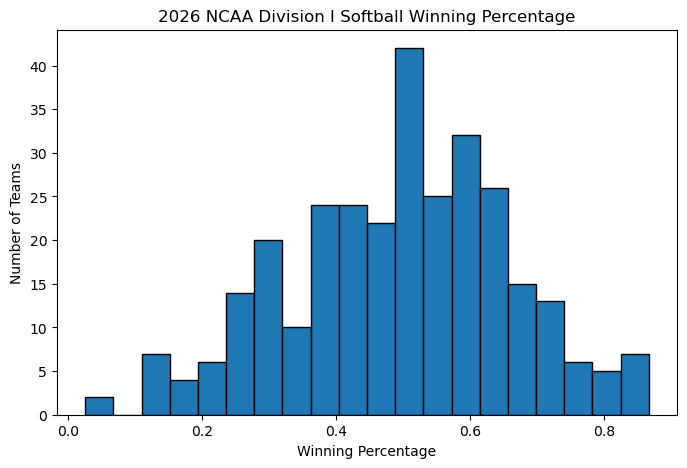

In [2]:
# Winning Percentage Distribution

print(master["WIN_PCT"].describe())

plt.figure(figsize=(8, 5))

plt.hist(
    master["WIN_PCT"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Winning Percentage")
plt.ylabel("Number of Teams")
plt.title("2026 NCAA Division I Softball Winning Percentage")

plt.show()

In [3]:
# Exploratory Analysis

analysis_vars = [
    # Offense
    "BA",
    "OBP",
    "SLG_PCT",
    "RUNS_PG",
    "RBI_PG",
    "HR_PG",
    "2B_PG",
    "3B_PG",
    "SB_PG",

    # Pitching
    "ERA",
    "WHIP",
    "HITS_ALLOWED_7",
    "K/BB",

    # Defense
    "FLD_PCT",
    "DP_PG"
]

# Calculate correlation of each statistic with winning percentage
win_correlations = (
    master[["WIN_PCT"] + analysis_vars]
    .corr()["WIN_PCT"]
    .drop("WIN_PCT")
    .sort_values(ascending=False)
)

print(win_correlations)

OBP               0.774426
RUNS_PG           0.769238
RBI_PG            0.762387
BA                0.735124
SLG_PCT           0.722558
K/BB              0.668494
FLD_PCT           0.623812
HR_PG             0.570290
2B_PG             0.536086
SB_PG             0.235691
DP_PG             0.213955
3B_PG             0.209380
HITS_ALLOWED_7   -0.813069
ERA              -0.821948
WHIP             -0.830587
Name: WIN_PCT, dtype: float64


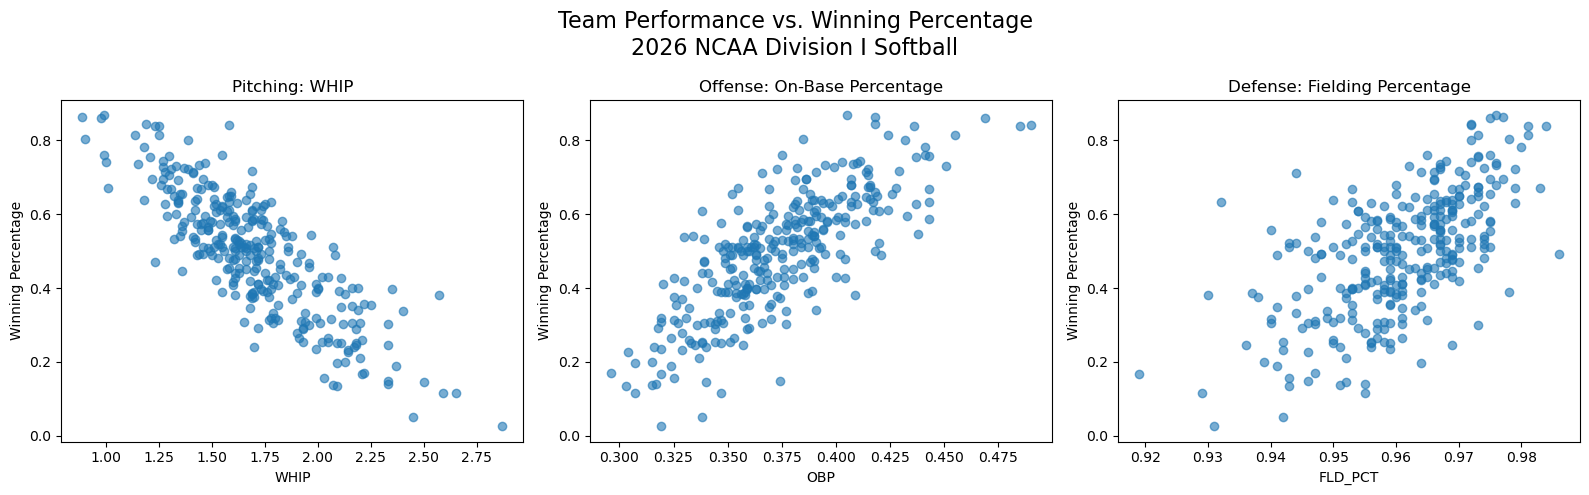

In [4]:
# WHIP, OBP, FLD_PCT vs Winning Percentages, Visualized

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variables = {
    "WHIP": "Pitching: WHIP",
    "OBP": "Offense: On-Base Percentage",
    "FLD_PCT": "Defense: Fielding Percentage"
}

for ax, (var, title) in zip(axes, variables.items()):
    ax.scatter(master[var], master["WIN_PCT"], alpha=0.6)

    ax.set_xlabel(var)
    ax.set_ylabel("Winning Percentage")
    ax.set_title(title)

plt.suptitle(
    "Team Performance vs. Winning Percentage\n"
    "2026 NCAA Division I Softball",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [5]:
# Multiple linear regression

model_data = master[
    ["WIN_PCT", "OBP", "WHIP", "FLD_PCT"]
].dropna()

# Predictor variables
X = model_data[
    ["OBP", "WHIP", "FLD_PCT"]
]

# Outcome variable
y = model_data["WIN_PCT"]

# Add an intercept to the model
X = sm.add_constant(X)

# Fit the regression
model = sm.OLS(y, X).fit()

# Display the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                WIN_PCT   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     717.0
Date:                Wed, 07 Oct 2026   Prob (F-statistic):          1.92e-136
Time:                        16:34:37   Log-Likelihood:                 436.15
No. Observations:                 304   AIC:                            -864.3
Df Residuals:                     300   BIC:                            -849.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9770      0.395     -2.472      0.0

In [6]:
# Compare explanatory power of regression models

y = master["WIN_PCT"]

# OBP only
X = sm.add_constant(master[["OBP"]])
obp_model = sm.OLS(y, X).fit()

# WHIP only
X = sm.add_constant(master[["WHIP"]])
whip_model = sm.OLS(y, X).fit()

# Fielding percentage only
X = sm.add_constant(master[["FLD_PCT"]])
fielding_model = sm.OLS(y, X).fit()

# OBP + WHIP
X = sm.add_constant(master[["OBP", "WHIP"]])
offense_pitching_model = sm.OLS(y, X).fit()

# Compare models
model_comparison = pd.DataFrame({
    "Model": [
        "OBP",
        "WHIP",
        "FLD_PCT",
        "OBP + WHIP",
        "OBP + WHIP + FLD_PCT"
    ],
    "R_squared": [
        obp_model.rsquared,
        whip_model.rsquared,
        fielding_model.rsquared,
        offense_pitching_model.rsquared,
        model.rsquared
    ]
})

model_comparison

,Model,R_squared
0,OBP,0.599736
1,WHIP,0.689875
2,FLD_PCT,0.389141
3,OBP + WHIP,0.874433
4,OBP + WHIP + FLD_PCT,0.877594


In [7]:
highest_fielding = (
    master[
        ["Team", "FLD_PCT", "WIN_PCT", "OBP", "WHIP"]
    ]
    .sort_values("FLD_PCT", ascending=False)
    .head(20)
)

highest_fielding

,Team,FLD_PCT,WIN_PCT,OBP,WHIP
151,Missouri,0.986,0.491,0.363,1.44
78,Florida St.,0.984,0.839,0.436,1.25
149,Mississippi St.,0.983,0.672,0.355,1.01
76,Florida,0.981,0.813,0.455,1.25
184,Oklahoma,0.981,0.839,0.485,1.23
11,Arkansas,0.980,0.783,0.441,1.18
87,Georgia,0.979,0.672,0.428,1.43
75,Fla. Atlantic,0.979,0.630,0.394,1.34
230,South Fla.,0.979,0.721,0.373,1.31
259,UAB,0.978,0.389,0.347,1.55


In [8]:
# Divide teams into four groups based on fielding percentage
master["FIELDING_GROUP"] = pd.qcut(
    master["FLD_PCT"],
    q=4,
    labels=[
        "Low",
        "Lower-Middle",
        "Upper-Middle",
        "High"
    ]
)

# Summarize winning percentage for each fielding group
fielding_summary = (
    master.groupby("FIELDING_GROUP", observed=False)["WIN_PCT"]
    .agg(["count", "mean", "median", "min", "max"])
)

print("Winning percentage by fielding group:")
display(fielding_summary)

# Define a winning team as a team above .500
master["WINNING_TEAM"] = master["WIN_PCT"] > 0.500

# Find how many teams in each fielding group have winning records
winning_by_fielding = (
    master.groupby("FIELDING_GROUP", observed=False)["WINNING_TEAM"]
    .agg(["count", "sum", "mean"])
)

winning_by_fielding["mean"] = winning_by_fielding["mean"] * 100

winning_by_fielding = winning_by_fielding.rename(
    columns={
        "sum": "Winning Teams",
        "mean": "Percent Winning"
    }
)

print("\nWinning teams by fielding group:")
display(winning_by_fielding)

Winning percentage by fielding group:


,count,mean,median,min,max
FIELDING_GROUP,,,,,
Low,86,0.376837,0.3830,0.026,0.712
Lower-Middle,72,0.441583,0.4275,0.234,0.679
Upper-Middle,83,0.546145,0.5560,0.196,0.759
High,63,0.649222,0.6610,0.300,0.867



Winning teams by fielding group:


,count,Winning Teams,Percent Winning
FIELDING_GROUP,,,
Low,86,21,24.418605
Lower-Middle,72,26,36.111111
Upper-Middle,83,53,63.855422
High,63,56,88.888889


In [9]:
# Strong-fielding teams that did not have winning records

strong_fielding_nonwinners = master[
    (master["FIELDING_GROUP"] == "High") &
    (master["WIN_PCT"] <= 0.500)
][
    ["Team", "FLD_PCT", "WIN_PCT", "OBP", "WHIP"]
].sort_values("WIN_PCT")

strong_fielding_nonwinners

,Team,FLD_PCT,WIN_PCT,OBP,WHIP
255,Toledo,0.973,0.300,0.336,1.96
259,UAB,0.978,0.389,0.347,1.55
244,Stony Brook,0.970,0.420,0.330,1.68
179,Northwestern St.,0.973,0.453,0.390,1.63
202,Radford,0.970,0.471,0.339,1.23
219,San Diego St.,0.974,0.480,0.368,1.53
151,Missouri,0.986,0.491,0.363,1.44


In [10]:
# Compare winning and non-winning teams
# among teams in the highest fielding group

high_fielding = master[
    master["FIELDING_GROUP"] == "High"
].copy()

high_fielding["RECORD_GROUP"] = high_fielding["WIN_PCT"].apply(
    lambda x: "Winning" if x > 0.500 else "Non-winning"
)

high_fielding_comparison = (
    high_fielding
    .groupby("RECORD_GROUP")[
        ["WIN_PCT", "FLD_PCT", "OBP", "WHIP"]
    ]
    .agg(["count", "mean", "median"])
)

high_fielding_comparison

WIN_PCT                   FLD_PCT                    OBP  \
               count      mean  median   count      mean median count   
RECORD_GROUP                                                            
Non-winning        7  0.429143  0.4530       7  0.974857  0.973     7   
Winning           56  0.676732  0.6725      56  0.974268  0.974    56   

                               WHIP                   
                  mean median count      mean median  
RECORD_GROUP                                          
Non-winning   0.353286  0.347     7  1.574286  1.550  
Winning       0.401643  0.403    56  1.381607  1.405

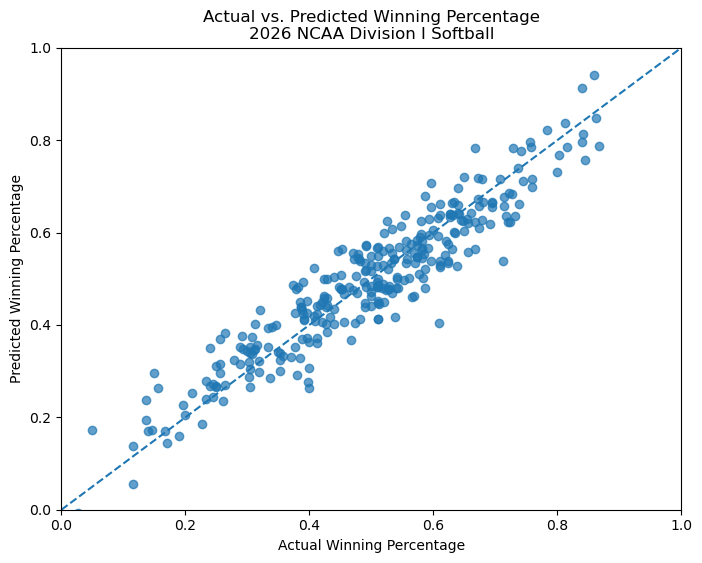

In [11]:
# Generate predicted winning percentages
model_data = model_data.copy()

X_final = model_data[["OBP", "WHIP", "FLD_PCT"]]
X_final = sm.add_constant(X_final)

model_data["PREDICTED_WIN_PCT"] = model.predict(X_final)

# Plot actual vs. predicted winning percentage
plt.figure(figsize=(8, 6))

plt.scatter(
    model_data["WIN_PCT"],
    model_data["PREDICTED_WIN_PCT"],
    alpha=0.7
)

# Perfect-prediction reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Actual Winning Percentage")
plt.ylabel("Predicted Winning Percentage")
plt.title(
    "Actual vs. Predicted Winning Percentage\n"
    "2026 NCAA Division I Softball"
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

In [12]:
# ============================================================
# FINAL RESULTS SUMMARY
# ============================================================

print("=" * 60)
print("2026 NCAA DIVISION I SOFTBALL ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. DATASET OVERVIEW
# ------------------------------------------------------------

print("\n1. DATASET OVERVIEW")
print("-" * 60)

print(f"Number of teams: {len(master)}")

print("\nWinning percentage:")
print(master["WIN_PCT"].describe())


# ------------------------------------------------------------
# 2. CORRELATIONS WITH WINNING PERCENTAGE
# ------------------------------------------------------------

print("\n\n2. CORRELATIONS WITH WINNING PERCENTAGE")
print("-" * 60)

print(win_correlations.round(3))


# ------------------------------------------------------------
# 3. REPRESENTATIVE PERFORMANCE STATISTICS
# ------------------------------------------------------------

print("\n\n3. KEY PERFORMANCE STATISTICS")
print("-" * 60)

for var in ["OBP", "WHIP", "FLD_PCT"]:
    correlation = master[var].corr(master["WIN_PCT"])

    print(
        f"{var} correlation with WIN_PCT: "
        f"{correlation:.3f}"
    )


# ------------------------------------------------------------
# 4. REGRESSION MODEL COMPARISON
# ------------------------------------------------------------

print("\n\n4. REGRESSION MODEL COMPARISON")
print("-" * 60)

display(model_comparison.round(3))


# ------------------------------------------------------------
# 5. FINAL MULTIPLE REGRESSION
# ------------------------------------------------------------

print("\n\n5. FINAL MULTIPLE REGRESSION")
print("-" * 60)

print(f"R-squared: {model.rsquared:.3f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.3f}")
print(f"Number of observations: {int(model.nobs)}")

print("\nCoefficients:")
display(
    pd.DataFrame({
        "Coefficient": model.params,
        "P-value": model.pvalues,
        "Lower 95% CI": model.conf_int()[0],
        "Upper 95% CI": model.conf_int()[1]
    }).round(4)
)


# ------------------------------------------------------------
# 6. FIELDING GROUP ANALYSIS
# ------------------------------------------------------------

print("\n\n6. FIELDING GROUP ANALYSIS")
print("-" * 60)

print("\nWinning percentage by fielding group:")
display(fielding_summary.round(3))

print("\nWinning teams by fielding group:")
display(winning_by_fielding.round(2))


# ------------------------------------------------------------
# 7. HIGH-FIELDING TEAMS
# ------------------------------------------------------------

print("\n\n7. HIGH-FIELDING TEAMS")
print("-" * 60)

print("\nHigh-fielding teams without winning records:")
display(strong_fielding_nonwinners)

print("\nWinning vs. non-winning teams within the high-fielding group:")
display(high_fielding_comparison.round(3))


# ------------------------------------------------------------
# 8. MODEL PREDICTION ERROR
# ------------------------------------------------------------

print("\n\n8. MODEL FIT")
print("-" * 60)

model_data["RESIDUAL"] = (
    model_data["WIN_PCT"] -
    model_data["PREDICTED_WIN_PCT"]
)

print(
    "Mean absolute prediction error:",
    round(model_data["RESIDUAL"].abs().mean(), 3)
)

print(
    "Root mean squared error:",
    round(
        np.sqrt(
            (model_data["RESIDUAL"] ** 2).mean()
        ),
        3
    )
)

print("\n" + "=" * 60)
print("END OF RESULTS SUMMARY")
print("=" * 60)

2026 NCAA DIVISION I SOFTBALL ANALYSIS

1. DATASET OVERVIEW
------------------------------------------------------------
Number of teams: 304

Winning percentage:
count    304.000000
mean       0.494845
std        0.165005
min        0.026000
25%        0.388750
50%        0.509500
75%        0.610250
max        0.867000
Name: WIN_PCT, dtype: float64


2. CORRELATIONS WITH WINNING PERCENTAGE
------------------------------------------------------------
OBP               0.774
RUNS_PG           0.769
RBI_PG            0.762
BA                0.735
SLG_PCT           0.723
K/BB              0.668
FLD_PCT           0.624
HR_PG             0.570
2B_PG             0.536
SB_PG             0.236
DP_PG             0.214
3B_PG             0.209
HITS_ALLOWED_7   -0.813
ERA              -0.822
WHIP             -0.831
Name: WIN_PCT, dtype: float64


3. KEY PERFORMANCE STATISTICS
------------------------------------------------------------
OBP correlation with WIN_PCT: 0.774
WHIP correlation with WIN

,Model,R_squared
0,OBP,0.600
1,WHIP,0.690
2,FLD_PCT,0.389
3,OBP + WHIP,0.874
4,OBP + WHIP + FLD_PCT,0.878




5. FINAL MULTIPLE REGRESSION
------------------------------------------------------------
R-squared: 0.878
Adjusted R-squared: 0.876
Number of observations: 304

Coefficients:


,Coefficient,P-value,Lower 95% CI,Upper 95% CI
const,-0.9770,0.0140,-1.7548,-0.1993
OBP,2.3594,0.0000,2.1314,2.5874
WHIP,-0.2877,0.0000,-0.3152,-0.2602
FLD_PCT,1.1210,0.0057,0.3284,1.9136




6. FIELDING GROUP ANALYSIS
------------------------------------------------------------

Winning percentage by fielding group:


...



7. HIGH-FIELDING TEAMS
------------------------------------------------------------

High-fielding teams without winning records:


,Team,FLD_PCT,WIN_PCT,OBP,WHIP
255,Toledo,0.973,0.300,0.336,1.96
259,UAB,0.978,0.389,0.347,1.55
244,Stony Brook,0.970,0.420,0.330,1.68
179,Northwestern St.,0.973,0.453,0.390,1.63
202,Radford,0.970,0.471,0.339,1.23
219,San Diego St.,0.974,0.480,0.368,1.53
151,Missouri,0.986,0.491,0.363,1.44



Winning vs. non-winning teams within the high-fielding group:


WIN_PCT               FLD_PCT                 OBP                \
               count   mean median   count   mean median count   mean median   
RECORD_GROUP                                                                   
Non-winning        7  0.429  0.453       7  0.975  0.973     7  0.353  0.347   
Winning           56  0.677  0.673      56  0.974  0.974    56  0.402  0.403   

              WHIP                
             count   mean median  
RECORD_GROUP                      
Non-winning      7  1.574  1.550  
Winning         56  1.382  1.405



8. MODEL FIT
------------------------------------------------------------
Mean absolute prediction error: 0.047
Root mean squared error: 0.058

END OF RESULTS SUMMARY
